# Dataset Characterization & EDA (Chapter 4 + Appendix)
Generates the **real** figures and tables that empirically support contribution C3
(feature redundancy and low-rank geometry on CICIDS2017 and UNSW-NB15).

Outputs saved to `reports/figures/` and `reports/tables/`:
- `eda_corr_heatmap_{cicids,unsw}.{png,pdf}` — feature correlation heatmaps
- `eda_redundancy_hist_{cicids,unsw}.{png,pdf}` — distribution of pairwise |Pearson r|
- `eda_pca_scree_{cicids,unsw}.{png,pdf}` — PCA scree + cumulative variance
- `eda_attack_categories_{cicids,unsw}.csv` — attack-category counts
- `eda_redundancy_summary.csv` — median redundancy, effective dimensionality
- `eda_top_redundant_pairs_{cicids,unsw}.csv` — most collinear feature pairs

Run top-to-bottom on Colab; then upload the produced PDF so the figures/tables can be integrated.

In [1]:
import sys
from pathlib import Path
try:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
except Exception: pass
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIG  = ROOT/'reports'/'figures'; TAB = ROOT/'reports'/'tables'
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)

# thesis figure style (serif, 300 dpi)
plt.rcParams.update({'font.family':'serif','font.size':10,'figure.dpi':120,'savefig.dpi':300,
                     'axes.grid':True,'grid.alpha':0.25})
GREEN='#1b4d3e'; ACCENT='#b00020'
print('paths ready:', ROOT.exists())

Mounted at /content/drive
paths ready: True


In [2]:
# ---- robust loaders: auto-discover parquet/csv for each dataset ----
def _find(patterns):
    for sub in ('data/processed','data/interim','data/raw'):
        d = ROOT/sub
        if not d.exists(): continue
        hits=[]
        for pat in patterns: hits += list(d.rglob(pat))
        if hits: return sorted(set(hits))
    return []

def load_numeric(files, drop_like=('id','srcip','dstip','sport','dsport','stime','ltime',
                                   'label','attack_cat','attack_category','attackcat')):
    if not files: return None, None, None
    if files[0].suffix=='.parquet':
        df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    else:
        df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
    low={c.lower():c for c in df.columns}
    cat = next((low[k] for k in ('attack_category','attack_cat','attackcat','label_cat') if k in low), None)
    feat = df.drop(columns=[c for c in df.columns if c.lower() in drop_like], errors='ignore')
    feat = feat.apply(pd.to_numeric, errors='coerce')
    feat = feat.loc[:, feat.notna().mean()>0.99].fillna(0.0)
    feat = feat.loc[:, feat.std(numeric_only=True)>0]      # drop constant columns
    return df, feat, cat

cic_files  = _find(['*cicids*.parquet','*CICIDS*.parquet','*cicids*processed*.parquet','*flow*.parquet'])
unsw_files = _find(['*unsw*.parquet','UNSW*.parquet','*UNSW*.parquet'])
print('CICIDS files:', [f.name for f in cic_files][:4])
print('UNSW   files:', [f.name for f in unsw_files][:4])

CICIDS files: []
UNSW   files: ['UNSW_NB15_testing-set.parquet', 'UNSW_NB15_training-set.parquet']


[cicids] no usable features found; skipping


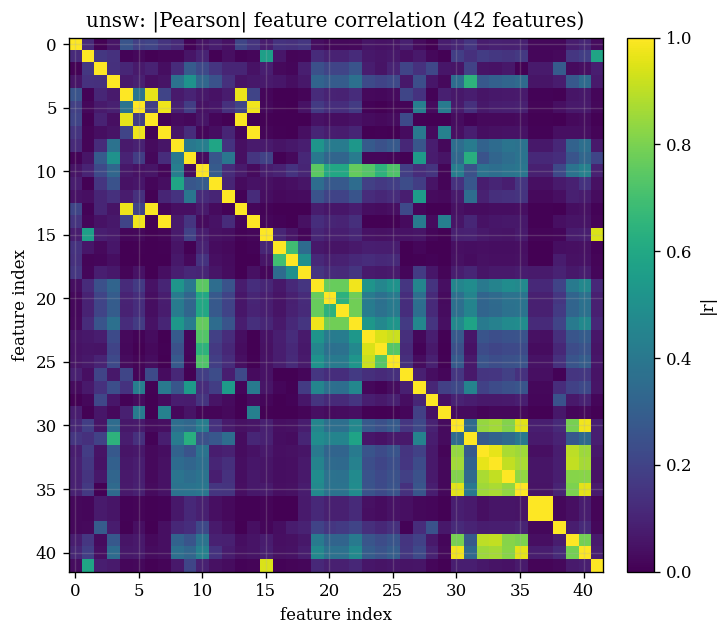

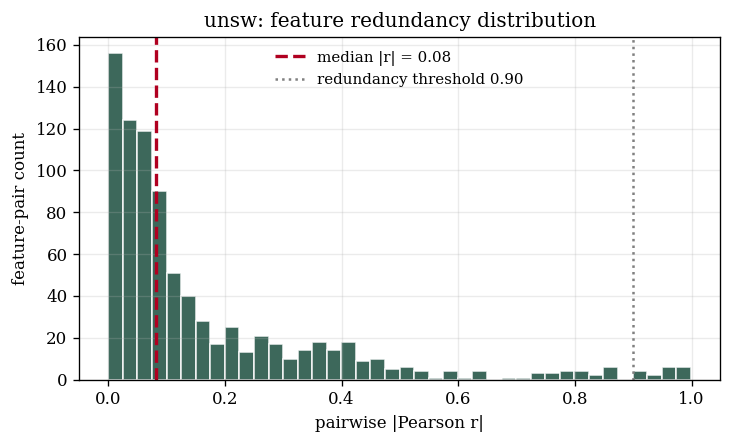

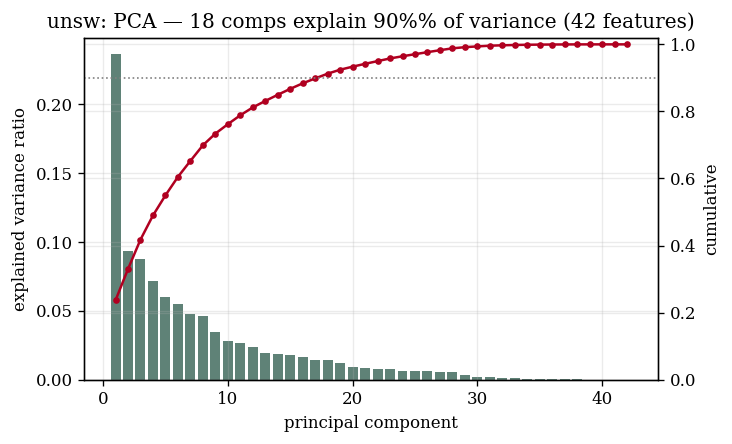

[unsw] attack categories: {'benign': 93000, 'generic': 58871, 'exploits': 44525, 'fuzzers': 24246, 'dos': 16353, 'reconnaissance': 13987, 'analysis': 2677, 'backdoor': 2329}
[unsw] n=257,673 d=42 | median|r|=0.082 | frac>0.9=0.02 | 90%% var in 18/42 comps | 99%% in 29/42


In [3]:
# ---- core EDA routine ----
def eda(name, files):
    df, feat, cat = load_numeric(files)
    if feat is None or feat.shape[1]<3:
        print(f'[{name}] no usable features found; skipping'); return None
    X = feat.to_numpy(float); cols=list(feat.columns)
    n,d = X.shape
    C = np.corrcoef(StandardScaler().fit_transform(X).T)
    absC = np.abs(C); iu=np.triu_indices(d,1); pair_abs=absC[iu]
    med_red=float(np.median(pair_abs)); hi_frac=float((pair_abs>0.9).mean())

    # correlation heatmap
    fig,ax=plt.subplots(figsize=(6.2,5.4))
    im=ax.imshow(absC,cmap='viridis',vmin=0,vmax=1)
    ax.set_title(f'{name}: |Pearson| feature correlation ({d} features)')
    ax.set_xlabel('feature index'); ax.set_ylabel('feature index')
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04,label='|r|'); fig.tight_layout()
    for e in ('png','pdf'): fig.savefig(FIG/f'eda_corr_heatmap_{name}.{e}',bbox_inches='tight')
    plt.show()

    # redundancy histogram
    fig,ax=plt.subplots(figsize=(6.2,3.8))
    ax.hist(pair_abs,bins=40,color=GREEN,alpha=0.85,edgecolor='white')
    ax.axvline(med_red,color=ACCENT,ls='--',lw=2,label=f'median |r| = {med_red:.2f}')
    ax.axvline(0.9,color='gray',ls=':',lw=1.5,label='redundancy threshold 0.90')
    ax.set_xlabel('pairwise |Pearson r|'); ax.set_ylabel('feature-pair count')
    ax.set_title(f'{name}: feature redundancy distribution'); ax.legend(frameon=False,fontsize=9)
    fig.tight_layout()
    for e in ('png','pdf'): fig.savefig(FIG/f'eda_redundancy_hist_{name}.{e}',bbox_inches='tight')
    plt.show()

    # PCA scree + cumulative
    Z=StandardScaler().fit_transform(X)
    pca=PCA().fit(Z); evr=pca.explained_variance_ratio_; cum=np.cumsum(evr)
    k90=int(np.argmax(cum>=0.90))+1; k99=int(np.argmax(cum>=0.99))+1
    fig,ax=plt.subplots(figsize=(6.2,3.8)); ax2=ax.twinx()
    kk=np.arange(1,len(evr)+1)
    ax.bar(kk,evr,color=GREEN,alpha=0.7,label='explained variance')
    ax2.plot(kk,cum,color=ACCENT,marker='o',ms=3,lw=1.5,label='cumulative')
    ax2.axhline(0.90,color='gray',ls=':',lw=1)
    ax.set_xlabel('principal component'); ax.set_ylabel('explained variance ratio')
    ax2.set_ylabel('cumulative'); ax2.set_ylim(0,1.02)
    ax.set_title(f'{name}: PCA — {k90} comps explain 90%% of variance ({d} features)')
    fig.tight_layout()
    for e in ('png','pdf'): fig.savefig(FIG/f'eda_pca_scree_{name}.{e}',bbox_inches='tight')
    plt.show()

    # top redundant pairs table
    pairs=[(cols[i],cols[j],float(absC[i,j])) for i,j in zip(*iu)]
    pairs.sort(key=lambda t:-t[2])
    pd.DataFrame(pairs[:20],columns=['feature_a','feature_b','abs_r']).to_csv(
        TAB/f'eda_top_redundant_pairs_{name}.csv',index=False)

    # attack categories
    if cat is not None:
        vc=df[cat].astype(str).str.strip().str.lower().replace(
            {'':'benign','normal':'benign','nan':'benign','-':'benign'}).value_counts()
        vc.rename('count').to_csv(TAB/f'eda_attack_categories_{name}.csv')
        print(f'[{name}] attack categories:', dict(list(vc.items())[:8]))

    print(f'[{name}] n={n:,} d={d} | median|r|={med_red:.3f} | frac>0.9={hi_frac:.2f} '
          f'| 90%% var in {k90}/{d} comps | 99%% in {k99}/{d}')
    return dict(dataset=name,n=int(n),d=int(d),median_abs_r=round(med_red,3),
                frac_pairs_gt_0p9=round(hi_frac,3),pca_k90=k90,pca_k99=k99,
                effective_dim_ratio=round(k90/d,3))

summ=[]
for nm,fs in [('cicids',cic_files),('unsw',unsw_files)]:
    r=eda(nm,fs)
    if r: summ.append(r)

In [4]:
# ---- redundancy summary table (the C3 evidence in one place) ----
if summ:
    S=pd.DataFrame(summ)
    S.to_csv(TAB/'eda_redundancy_summary.csv',index=False)
    print(S.to_string(index=False))
    print('\nSaved figures:');
    for p in sorted(FIG.glob('eda_*')): print('  ', p.name)
    print('Saved tables:')
    for p in sorted(TAB.glob('eda_*')): print('  ', p.name)
else:
    print('No datasets characterized — check the file paths printed above.')

dataset      n  d  median_abs_r  frac_pairs_gt_0p9  pca_k90  pca_k99  effective_dim_ratio
   unsw 257673 42         0.082              0.021       18       29                0.429

Saved figures:
   eda_corr_heatmap_unsw.pdf
   eda_corr_heatmap_unsw.png
   eda_pca_scree_unsw.pdf
   eda_pca_scree_unsw.png
   eda_redundancy_hist_unsw.pdf
   eda_redundancy_hist_unsw.png
Saved tables:
   eda_attack_categories_unsw.csv
   eda_redundancy_summary.csv
   eda_top_redundant_pairs_unsw.csv
